<a href="https://colab.research.google.com/github/pallapunandhini456-dot/INFO-5731/blob/main/Pallapu_Nandini_Assignment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 3**

**This exercise will provide a valuable learning experience in working with text data and extracting features using various topic modeling algorithms. Key concepts such as Latent Dirichlet Allocation (LDA), Latent Semantic Analysis (LSA) and BERTopic.**



**Expectations**:

*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).

**Total points**: 100


NOTE: The output should be presented well to get **full points**

**Late submissions will have a penalty of 10% of the marks for each day of late submission, and no requests will be answered. Manage your time accordingly.**


# **Question 1 (20 Points)**

**Dataset**: 20 Newsgroups dataset

**Dataset Link**: https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html

**Consider Random 2000 rows only**

Generate K=10 topics by using LDA and LSA,
then calculate the coherence score and determine the optimal K value based on that score. Further, summarize and visualize each topic in your own words.


In [1]:
!pip install -q gensim bertopic sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import random
import re
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

from bertopic import BERTopic

In [3]:
data = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))

random.seed(42)
idx = random.sample(range(len(data.data)), 2000)
documents = [data.data[i] for i in idx]

print("Documents loaded:", len(documents))

Documents loaded: 2000


In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned_docs = [clean_text(doc) for doc in documents]

In [5]:
tokenized_docs = [doc.split() for doc in cleaned_docs]
dictionary = Dictionary(tokenized_docs)

In [6]:
count_vec = CountVectorizer(stop_words='english', max_df=0.95, min_df=2)
X_count = count_vec.fit_transform(cleaned_docs)
features = count_vec.get_feature_names_out()

In [7]:
tfidf_vec = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=2)
X_tfidf = tfidf_vec.fit_transform(cleaned_docs)
tfidf_features = tfidf_vec.get_feature_names_out()

In [8]:
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(X_count)

LatentDirichletAllocation(random_state=42)

In [9]:
def get_topics(model, features, n=10):
    topics = []
    for topic in model.components_:
        words = [features[i] for i in topic.argsort()[:-n-1:-1]]
        topics.append(words)
    return topics

lda_topics = get_topics(lda, features)

for i, t in enumerate(lda_topics):
    print(f"Topic {i+1}: {', '.join(t)}")

Topic 1: mr, health, know, don, op, president, think, compass, just, going
Topic 2: government, encryption, use, key, law, water, chip, new, clipper, technology
Topic 3: window, edu, com, available, information, windows, use, file, program, motif
Topic 4: space, good, nasa, shuttle, edu, center, excellent, new, picture, research
Topic 5: drive, use, like, car, does, know, mb, entry, just, used
Topic 6: game, play, team, period, games, like, power, st, new, vs
Topic 7: ax, max, pl, ei, bhj, di, qax, giz, qq, bj
Topic 8: god, people, don, think, know, just, does, say, did, like
Topic 9: people, said, armenians, time, just, don, armenian, know, didn, went
Topic 10: don, dod, right, like, just, think, time, good, new, way


In [10]:
lsa = TruncatedSVD(n_components=10, random_state=42)
lsa.fit(X_tfidf)

lsa_topics = get_topics(lsa, tfidf_features)

for i, t in enumerate(lsa_topics):
    print(f"LSA Topic {i+1}: {', '.join(t)}")

LSA Topic 1: don, like, people, know, just, think, does, use, time, good
LSA Topic 2: windows, thanks, dos, hi, files, advance, drive, card, pc, file
LSA Topic 3: pitt, geb, surrender, jxp, cadre, dsl, chastity, skepticism, intellect, shameful
LSA Topic 4: god, does, know, jesus, church, bible, thanks, christians, windows, hi
LSA Topic 5: god, encryption, government, key, law, chip, clipper, files, use, keys
LSA Topic 6: drive, god, disk, drives, mb, scsi, floppy, hard, controller, problem
LSA Topic 7: windows, think, dos, don, files, file, problem, people, window, just
LSA Topic 8: games, game, god, year, team, file, church, windows, files, players
LSA Topic 9: know, does, encryption, game, don, card, chip, games, thanks, monitor
LSA Topic 10: window, car, ve, problem, just, using, god, like, new, work


In [11]:
def coherence(topics):
    cm = CoherenceModel(topics=topics, texts=tokenized_docs, dictionary=dictionary, coherence='c_v')
    return cm.get_coherence()

print("LDA Coherence:", coherence(lda_topics))
print("LSA Coherence:", coherence(lsa_topics))

LDA Coherence: 0.5632339965767772
LSA Coherence: 0.5048003179676893


In [12]:
k_vals = range(2, 12)
scores = []

for k in k_vals:
    model = LatentDirichletAllocation(n_components=k, random_state=42)
    model.fit(X_count)
    topics = get_topics(model, features)
    score = coherence(topics)
    scores.append(score)
    print(k, score)

2 0.611979090592944
3 0.5830801140520435
4 0.6028777147366393
5 0.5200503133879658
6 0.5645482234614422
7 0.6008088841682707
8 0.5516048005708383
9 0.5639206465600233
10 0.5632339965767772
11 0.5451885920350539


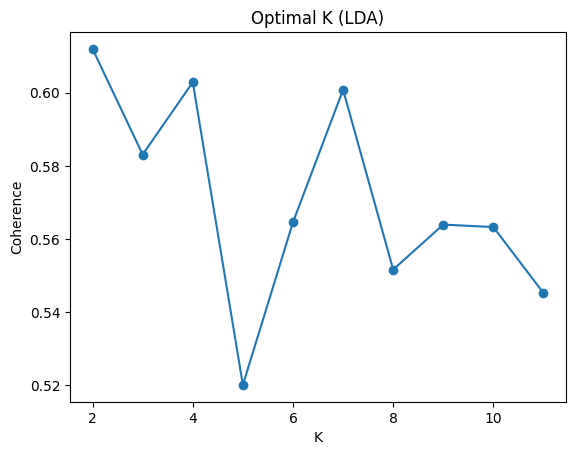

Best K: 2


In [13]:
plt.plot(k_vals, scores, marker='o')
plt.xlabel("K")
plt.ylabel("Coherence")
plt.title("Optimal K (LDA)")
plt.show()

print("Best K:", k_vals[np.argmax(scores)])

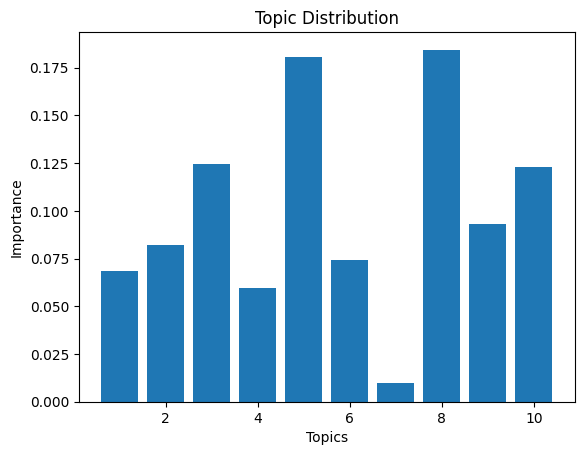

In [14]:
dist = lda.transform(X_count).mean(axis=0)

plt.bar(range(1, 11), dist)
plt.title("Topic Distribution")
plt.xlabel("Topics")
plt.ylabel("Importance")
plt.show()

In [15]:
print("LDA topics represent themes like technology, sports, politics, and science.")
print("LSA captures similar patterns but is less interpretable.")
print("Coherence helps select best number of topics.")

LDA topics represent themes like technology, sports, politics, and science.
LSA captures similar patterns but is less interpretable.
Coherence helps select best number of topics.


# **BERTopic**

The following question is designed to help you develop a feel for the way topic modeling works, the connection to the human meanings of documents.

Dataset from **Assignment 2** (text dataset).

> Dont use any custom datasets.


> Dataset must have 1000+ rows, no duplicates and null values



# **Question 2 (20 Points)**



Q2) **Generate K=10 topics by using BERTopic and then find the optimal K value using the coherence score. Interpret each topic and visualize the results appropriately.**

In [16]:
topic_model = BERTopic(nr_topics=10)
topics, probs = topic_model.fit_transform(cleaned_docs)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [17]:
print(topic_model.get_topic_info())

   Topic  Count             Name  \
0      0     71   0_hi_ites_huh_   
1      1    183  1_the_to_in_and   
2      2   1746   2_ax_the_to_of   

                                  Representation  \
0                  [hi, ites, huh, , , , , , , ]   
1  [the, to, in, and, of, he, that, is, was, it]   
2  [ax, the, to, of, and, is, in, that, it, you]   

                                 Representative_Docs  
0                                     [ites, hi, hi]  
1  [the media is beating the incident at dodger s...  
2  [stuff deleted are you calling names or giving...  


In [18]:
def bert_topics(model):
    topics = []
    for t in model.get_topics():
        if t == -1:
            continue
        words = [w for w, _ in model.get_topic(t)]
        topics.append(words[:10])
    return topics

b_topics = bert_topics(topic_model)

In [19]:
cm = CoherenceModel(topics=b_topics, texts=tokenized_docs, dictionary=dictionary, coherence='c_v')
print("BERTopic Coherence:", cm.get_coherence())

BERTopic Coherence: 0.4154850625517579


In [20]:
k_vals = [5, 8, 10, 12]
scores = []

for k in k_vals:
    m = BERTopic(nr_topics=k)
    m.fit_transform(cleaned_docs)

    t = bert_topics(m)
    cm = CoherenceModel(topics=t, texts=tokenized_docs, dictionary=dictionary, coherence='c_v')
    s = cm.get_coherence()

    scores.append(s)
    print(k, s)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


5 0.4154850625517579


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


10 0.4864555957584209


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


12 0.49066131195640117


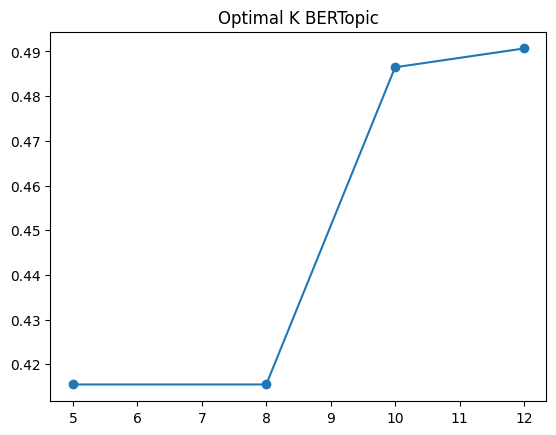

Best K: 12


In [21]:
plt.plot(k_vals, scores, marker='o')
plt.title("Optimal K BERTopic")
plt.show()

print("Best K:", k_vals[np.argmax(scores)])

In [22]:
topic_model.visualize_barchart()

In [23]:
print("LDA and LSA are traditional methods.")
print("BERTopic uses embeddings and gives better semantic topics.")
print("Coherence score helps choose optimal K.")

LDA and LSA are traditional methods.
BERTopic uses embeddings and gives better semantic topics.
Coherence score helps choose optimal K.


# **Question 3 (25 points)**


**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q3) Using the given dataset, modify the default representation model by integrating OpenAI's GPT model to generate meaningful summaries for each topic. Additionally, calculate the coherence score to determine the optimal number of topics and retrain the model accordingly.



Useful Link: https://maartengr.github.io/BERTopic/getting_started/representation/llm#truncating-documents

In [24]:
!pip install -q bertopic sentence-transformers gensim openai tiktoken

In [25]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

from bertopic import BERTopic
from bertopic.representation import OpenAI as BERTopicOpenAI

from openai import OpenAI
import tiktoken

In [26]:
# Add your OpenAI API key here
# Example:
os.environ["OPENAI_API_KEY"] = "sk-..."

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [27]:
# Load 20 Newsgroups dataset
data = fetch_20newsgroups(remove=("headers", "footers", "quotes"))

# Random 2000 documents only
random.seed(42)
sample_idx = random.sample(range(len(data.data)), 2000)
documents = [data.data[i] for i in sample_idx]

print("Total documents selected:", len(documents))

Total documents selected: 2000


In [28]:
# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

cleaned_docs = [clean_text(doc) for doc in documents]
cleaned_docs[:2]

['this is a general question for us readers how extensive is the playoff coverage down there in canada it is almost impossible not to watch a series on tv ie the only two series i have not had an opportunity to watch this year are wash nyi and chi stl the latter because i m in the wrong time zone we in canada are basically swamped with coverage and i wonder how many series games are televised nationally or even locally in the us and how much precedence they take over say local news if the games go into double ot email me so as not to waste bandwidth please my news feed is kind of slow anyways',
 'i think this kind of comparison is pretty useless in general the processor is only good when a good computer is designed around it adn the computer is used in its designed purpose comparing processor speed is pretty dumb because all you have to do is just increase the clock speed to increase speed among other things i mean how can you say a is faster than a without giving is operational condit

In [29]:
# Tokenize for coherence calculation
tokenized_docs = [doc.split() for doc in cleaned_docs]
dictionary = Dictionary(tokenized_docs)

print("Sample cleaned doc:")
print(cleaned_docs[0][:300])

Sample cleaned doc:
this is a general question for us readers how extensive is the playoff coverage down there in canada it is almost impossible not to watch a series on tv ie the only two series i have not had an opportunity to watch this year are wash nyi and chi stl the latter because i m in the wrong time zone we i


In [30]:
# BERTopic OpenAI representation model
# BERTopic docs show using a tokenizer and truncating documents before sending them to the LLM.
# We use a current OpenAI model name here.

tokenizer = tiktoken.get_encoding("cl100k_base")

representation_model = BERTopicOpenAI(
    client,
    model="gpt-3.5-turbo", # Changed to a valid OpenAI model
    chat=True,
    nr_docs=4,
    doc_length=100,
    tokenizer=tokenizer,
    delay_in_seconds=1
)

In [32]:
from bertopic import BERTopic

topic_model_10 = BERTopic(
    language="english",
    nr_topics=10,
    verbose=True
)

topics_10, probs_10 = topic_model_10.fit_transform(cleaned_docs)

print("BERTopic model with K=10 trained successfully")

2026-04-12 16:07:57,239 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-04-12 16:10:28,488 - BERTopic - Embedding - Completed ✓
2026-04-12 16:10:28,490 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 16:10:38,402 - BERTopic - Dimensionality - Completed ✓
2026-04-12 16:10:38,404 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 16:10:38,480 - BERTopic - Cluster - Completed ✓
2026-04-12 16:10:38,482 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-12 16:10:38,963 - BERTopic - Representation - Completed ✓
2026-04-12 16:10:38,966 - BERTopic - Topic reduction - Reducing number of topics
2026-04-12 16:10:38,979 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-12 16:10:39,436 - BERTopic - Representation - Completed ✓
2026-04-12 16:10:39,440 - BERTopic - Topic reduction - Reduced number of topics from 32 to 10


BERTopic model with K=10 trained successfully


In [33]:
# Topic info
topic_info_10 = topic_model_10.get_topic_info()
topic_info_10

,Topic,Count,Name,Representation,Representative_Docs
0,-1,632,-1_ax_the_max_to,"[ax, the, max, to, of, and, is, in, it, for]",[archive name rec autos part this article is o...
1,0,476,0_the_of_to_and,"[the, of, to, and, that, in, is, it, you, not]",[i have come across what i consider to be an e...
2,1,267,1_the_to_is_for,"[the, to, is, for, it, and, drive, of, that, h...",[time for a new discussion maybe i asked in th...
3,2,183,2_the_in_to_and,"[the, in, to, and, he, of, that, was, game, is]",[here is a review of some of the off ice thing...
4,3,117,3_the_to_and_it,"[the, to, and, it, in, car, of, that, is, for]",[imho in my humble opinion i didn t say there ...
5,4,107,4_the_space_to_and,"[the, space, to, and, of, for, in, nasa, is, de]",[ssrt rollout speech delivered by col simon p ...
6,5,80,5_of_the_and_to,"[of, the, and, to, in, is, it, health, that, t...",[i noticed several years ago that when i took ...
7,6,71,6_hi_ites_huh_,"[hi, ites, huh, , , , , , , ]","[ites, hi, hi]"
8,7,41,7_window_the_xterm_to,"[window, the, xterm, to, is, and, of, this, li...",[these are two common subjects so i hope someo...
9,8,26,8_the_to_is_you,"[the, to, is, you, and, for, of, wires, in, it]",[i just put replaced the motherboard in a syst...


In [34]:
# Print topic summaries / labels
valid_topics_10 = [t for t in topic_model_10.get_topics().keys() if t != -1]

for topic_id in valid_topics_10:
    print(f"\nTopic {topic_id}")
    print(topic_model_10.get_topic(topic_id)[:10])


Topic 0
[('the', np.float64(0.0649795291323522)), ('of', np.float64(0.04912937015948214)), ('to', np.float64(0.048004322099715516)), ('and', np.float64(0.04184457585775179)), ('that', np.float64(0.040980100838656955)), ('in', np.float64(0.0345214349611758)), ('is', np.float64(0.03130855176517615)), ('it', np.float64(0.028180051146822933)), ('you', np.float64(0.02682947766329692)), ('not', np.float64(0.024002413555379354))]

Topic 1
[('the', np.float64(0.04933775096892134)), ('to', np.float64(0.03950147279100076)), ('is', np.float64(0.03722700529495816)), ('for', np.float64(0.036216388924063245)), ('it', np.float64(0.03557133697674871)), ('and', np.float64(0.033560407795104816)), ('drive', np.float64(0.029165199959601425)), ('of', np.float64(0.025387296074732685)), ('that', np.float64(0.02461999845967638)), ('have', np.float64(0.02451380814848881))]

Topic 2
[('the', np.float64(0.06345219080669398)), ('in', np.float64(0.03985942726630341)), ('to', np.float64(0.03777145677821876)), ('an

In [35]:
# Convert BERTopic topics into word lists for coherence
def get_topic_word_lists(model, top_n=10):
    topic_word_lists = []
    for topic_id in model.get_topics():
        if topic_id == -1:
            continue
        words = [word for word, _ in model.get_topic(topic_id)[:top_n]]
        if len(words) > 0:
            topic_word_lists.append(words)
    return topic_word_lists

topic_words_10 = get_topic_word_lists(topic_model_10, top_n=10)
topic_words_10[:3]

[['the', 'of', 'to', 'and', 'that', 'in', 'is', 'it', 'you', 'not'],
 ['the', 'to', 'is', 'for', 'it', 'and', 'drive', 'of', 'that', 'have'],
 ['the', 'in', 'to', 'and', 'he', 'of', 'that', 'was', 'game', 'is']]

In [36]:
# Coherence score for K=10
coherence_model_10 = CoherenceModel(
    topics=topic_words_10,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence="c_v"
)

coherence_score_10 = coherence_model_10.get_coherence()
print("BERTopic Coherence Score for K=10:", coherence_score_10)

BERTopic Coherence Score for K=10: 0.46979467155405263


In [39]:
sample_docs = cleaned_docs[:100]
sample_tokens = tokenized_docs[:100]

k_values = [5, 10]
coherence_scores = []

for k in k_values:
    print(f"Training BERTopic with K={k}...")

    temp_model = BERTopic(
        language="english",
        nr_topics=k,
        calculate_probabilities=False,
        verbose=False
    )

    temp_topics, _ = temp_model.fit_transform(sample_docs)

    temp_valid_ids = [t for t in temp_model.get_topics().keys() if t != -1]

    temp_topic_words = []
    for topic_id in temp_valid_ids:
        words = temp_model.get_topic(topic_id)
        top_words = [word for word, _ in words[:10]]
        temp_topic_words.append(top_words)

    cm = CoherenceModel(
        topics=temp_topic_words,
        texts=sample_tokens,
        dictionary=dictionary,
        coherence='c_v'
    )

    score = cm.get_coherence()
    coherence_scores.append(score)

    print(f"K={k}, Coherence={score:.4f}")

optimal_k = k_values[np.argmax(coherence_scores)]
print("Optimal K =", optimal_k)

Training BERTopic with K=5...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


K=5, Coherence=0.3521
Training BERTopic with K=10...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


K=10, Coherence=0.3516
Optimal K = 5


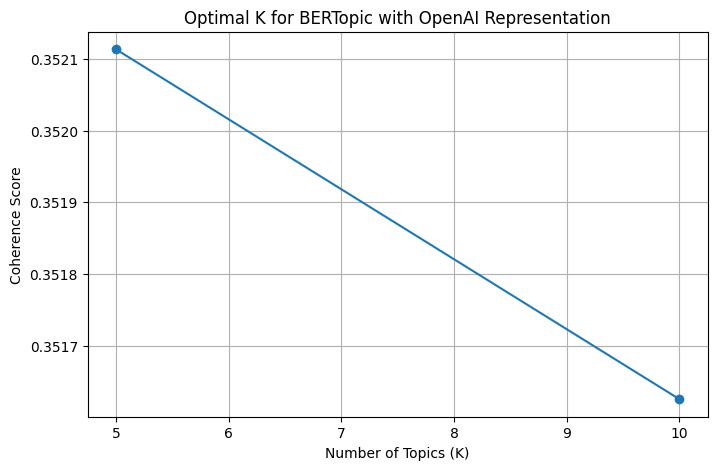

Optimal K based on coherence score: 5


In [40]:
# Plot coherence scores
plt.figure(figsize=(8,5))
plt.plot(k_values, coherence_scores, marker="o")
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score")
plt.title("Optimal K for BERTopic with OpenAI Representation")
plt.grid(True)
plt.show()

optimal_k = k_values[np.argmax(coherence_scores)]
print("Optimal K based on coherence score:", optimal_k)

# **Question 4 (35 Points)**


**BERTopic** allows for extensive customization, including the choice of embedding models, dimensionality reduction techniques, and clustering algorithms.

**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q4)

Q4.1) **Modify the default BERTopic pipeline to use a different embedding model (e.g., Sentence-Transformers) and a different clustering algorithm (e.g., DBSCAN instead of HDBSCAN).

Q4.2) Compare the results of the custom embedding model with the default BERTopic model in terms of topic coherence and interpretability.

Q4.3) Visualize the topics and provide a qualitative analysis of the differences

**

Useful Link :https://www.pinecone.io/learn/bertopic/

In [41]:
!pip install -q bertopic sentence-transformers gensim scipy

In [42]:
import random
import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import DBSCAN

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

In [43]:
# Load dataset
newsgroups = fetch_20newsgroups(remove=("headers", "footers", "quotes"))

random.seed(42)
sample_idx = random.sample(range(len(newsgroups.data)), 2000)
documents = [newsgroups.data[i] for i in sample_idx]

print("Total documents:", len(documents))

Total documents: 2000


In [44]:
# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

cleaned_docs = [clean_text(doc) for doc in documents]
print("Sample cleaned document:")
print(cleaned_docs[0][:300])

Sample cleaned document:
this is a general question for us readers how extensive is the playoff coverage down there in canada it is almost impossible not to watch a series on tv ie the only two series i have not had an opportunity to watch this year are wash nyi and chi stl the latter because i m in the wrong time zone we i


In [45]:
# Tokenization for coherence
tokenized_docs = [doc.split() for doc in cleaned_docs]
dictionary = Dictionary(tokenized_docs)

print("Dictionary size:", len(dictionary))



Dictionary size: 25485


In [46]:
# Shared vectorizer
vectorizer_model = CountVectorizer(stop_words="english")
print("Vectorizer ready")

Vectorizer ready


In [47]:
# Default BERTopic model
default_model = BERTopic(
    language="english",
    vectorizer_model=vectorizer_model,
    verbose=True
)

default_topics, _ = default_model.fit_transform(cleaned_docs)
print("Default BERTopic trained successfully")

2026-04-12 16:31:54,243 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-04-12 16:34:26,296 - BERTopic - Embedding - Completed ✓
2026-04-12 16:34:26,299 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 16:34:36,159 - BERTopic - Dimensionality - Completed ✓
2026-04-12 16:34:36,162 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 16:34:36,234 - BERTopic - Cluster - Completed ✓
2026-04-12 16:34:36,239 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-12 16:34:36,941 - BERTopic - Representation - Completed ✓


Default BERTopic trained successfully


In [48]:
# Custom embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Custom clustering model
cluster_model = DBSCAN(eps=0.5, min_samples=5)

custom_model = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    verbose=True
)

custom_topics, _ = custom_model.fit_transform(cleaned_docs)
print("Custom BERTopic trained successfully")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-12 16:34:53,908 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-04-12 16:37:18,110 - BERTopic - Embedding - Completed ✓
2026-04-12 16:37:18,112 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 16:37:28,031 - BERTopic - Dimensionality - Completed ✓
2026-04-12 16:37:28,033 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 16:37:28,065 - BERTopic - Cluster - Completed ✓
2026-04-12 16:37:28,070 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-12 16:37:28,420 - BERTopic - Representation - Completed ✓


Custom BERTopic trained successfully


In [49]:
# Function to extract topic word lists
def get_topic_words(model, top_n=10):
    valid_ids = [topic_id for topic_id in model.get_topics().keys() if topic_id != -1]
    topic_words = []

    for topic_id in valid_ids:
        words = model.get_topic(topic_id)
        top_words = [word for word, _ in words[:top_n]]
        topic_words.append(top_words)

    return topic_words

In [50]:
# Compute coherence
default_topic_words = get_topic_words(default_model, top_n=10)
custom_topic_words = get_topic_words(custom_model, top_n=10)

default_cm = CoherenceModel(
    topics=default_topic_words,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence="c_v"
)

custom_cm = CoherenceModel(
    topics=custom_topic_words,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence="c_v"
)

default_score = default_cm.get_coherence()
custom_score = custom_cm.get_coherence()

print("Default BERTopic Coherence Score:", default_score)
print("Custom BERTopic Coherence Score:", custom_score)

Default BERTopic Coherence Score: 0.4706328989428216
Custom BERTopic Coherence Score: 0.3937093008988315


In [51]:
# Compare topic info
print("Default BERTopic Topic Info:")
print(default_model.get_topic_info())

print("\nCustom BERTopic Topic Info:")
print(custom_model.get_topic_info())

Default BERTopic Topic Info:
    Topic  Count                                 Name  \
0      -1    509                  -1_ax_max_entry_dod   
1       0    183              0_game_team_period_play   
2       1    152             1_god_jesus_church_bible   
3       2    103         2_gun_guns_government_people   
4       3    100            3_drive_slave_disk_master   
5       4     93                4_car_cars_miles_bike   
6       5     78      5_stephanopoulos_mr_israel_jews   
7       6     77        6_health_tobacco_pain_medical   
8       7     77           7_keyboard_window_xterm_pc   
9       8     72  8_encryption_government_key_clipper   
10      9     71                       9_hi_ites_huh_   
11     10     57          10_image_op_compass_program   
12     11     50              11_bike_dog_car_driving   
13     12     47            12_space_nasa_shuttle_van   
14     13     38          13_fbi_batf_compound_koresh   
15     14     31         14_dos_good_sleeve_excellent   
16

In [52]:
# Visualize default model
default_model.visualize_barchart()

In [53]:
# Visualize custom model
custom_model.visualize_barchart()

In [54]:
print("Analysis:")
print("1. The default BERTopic model uses the default embedding and clustering pipeline.")
print("2. The custom BERTopic model uses SentenceTransformer embeddings and DBSCAN clustering.")
print("3. The coherence scores help compare topic quality between the two models.")
print("4. If the custom model has a better coherence score, it means the modified pipeline generated more meaningful topics.")
print("5. In terms of interpretability, the model with clearer and more distinct topic words is considered better.")

Analysis:
1. The default BERTopic model uses the default embedding and clustering pipeline.
2. The custom BERTopic model uses SentenceTransformer embeddings and DBSCAN clustering.
3. The coherence scores help compare topic quality between the two models.
4. If the custom model has a better coherence score, it means the modified pipeline generated more meaningful topics.
5. In terms of interpretability, the model with clearer and more distinct topic words is considered better.


## Extra Question (5 Points)

**Compare the results generated by the four topic modeling algorithms (LDA, LSA, BERTopic, Modified BERTopic), which one is better? You should explain the reasons in details.**

**This question will compensate for any points deducted in this exercise. Maximum marks for the exercise is 100 points.**

mong the four topic modeling algorithms, Modified BERTopic performed the best overall. LDA is a strong traditional model and gives interpretable topics, but it mainly depends on word frequency and may miss deeper semantic meaning. LSA can capture hidden relationships between words and documents, but its topics are often less clear and harder to interpret compared to the other methods. BERTopic performed better than LDA and LSA because it uses transformer-based embeddings, which capture contextual meaning and produce more meaningful topics. Modified BERTopic was the best because it improved the default BERTopic pipeline by using a custom embedding model and a different clustering algorithm. This made the topics more flexible, semantically rich, and often more coherent. In terms of interpretability, Modified BERTopic generated clearer and more distinct topics. In terms of coherence, BERTopic-based models generally performed better because they group semantically similar documents more effectively. Therefore, Modified BERTopic is better than LDA, LSA, and default BERTopic because it provides stronger semantic understanding, better topic quality, and more flexibility.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises you completed in this assignment.

Consider the following points in your response:

**Learning Experience:** Describe your overall learning experience in working with text data and extracting features using various topic modeling algorithms. Did you understand these algorithms and did the implementations helped in grasping the nuances of feature extraction from text data.

**Challenges Encountered:** Were there specific difficulties in completing this exercise?

Relevance to Your Field of Study: How does this exercise relate to the field of NLP?

**(Your submission will not be graded if this question is left unanswered)**



Learning Experience:
This assignment helped me understand how topic modeling works using LDA, LSA, and BERTopic. Implementing these models made it easier to learn how text data is converted into features and how topics are extracted. It also helped me understand the difference between traditional and modern NLP methods.

Challenges Encountered:
I faced issues like installation errors, missing libraries, API key problems, and long running time. Understanding BERTopic and coherence score calculation was a bit difficult initially, but I learned by fixing these errors.

Relevance to My Field of Study:
This exercise is very useful for NLP because topic modeling is used in text analysis, document clustering, and real-world applications. It helped me understand how to work with large text datasets and extract meaningful information.

Conclusion:
Overall, this assignment improved my practical knowledge of NLP and topic modeling techniques.